# RANBP17_exp — **Tile-level** pixel colocalization of TDP-43 in RANBP17

## Goal: test whether TDP-43 is enriched in RANBP17-positive pixels (P(TDP+ | RANBP17+)) above what is expected by chance — computed on **preprocessed NPY tiles** instead of full TIFF sites.

Adapted from `pixel_level_colocalization_RANBP17_TDP43.ipynb` (site-level). Differences:
- Reads **preprocessed tiles** from `input/images/processed/RANBP17_exp/<batch>/<cell_line>/<condition>/<marker>/<file>.npy`
  (shape `[n_tiles, 100, 100, 2]`, **already rescaled to [0,1]**; channel 0 = marker, channel 1 = DAPI).
- The processed layout has **no `panel` / `rep` directory** — both are encoded in the filename
  (`rep2_r03c04f07-ch1t1_panelA_iW11_processed.npy`) and parsed from it.
- RANBP17 (`ch1`) and TDP-43 (`ch3`) tiles of the same site share one nucleus segmentation, so
  `tile_index i` corresponds across markers → pairing is by `(batch, cell_line, condition, rep, site, tile_index)`.
- **No rescaling** (tiles are pre-processed). **No fixed-threshold option** — adaptive `mean+K·sd` only, to stay close to the original.
- `PANELS` / `REPS` are optional global filters (set to `None` to disable).

Pipeline:
1. List tile paths per batch/cell_line/condition/marker; explode each NPY into one row per tile.
2. For each tile, pair RANBP17 (ch1) with TDP-43 (ch3) and compute `fraction_overlap` (real) and `fraction_overlap_rotated` (TDP rotated 90° as the spatial-random null).
3. Plot distributions; paired Wilcoxon real vs rotated.
4. Per-condition / per-rep aggregates and reproducibility plots; effect-size report (runs only when ≥2 batches are present).

## Imports

In [41]:
import os
import sys
import re
import numpy as np
import pandas as pd
%matplotlib inline

from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

os.environ['NOVA_HOME'] = '/home/projects/hornsteinlab/Collaboration/NOVA'
sys.path.insert(1, os.getenv('NOVA_HOME'))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")

# Reuse the shared per-marker colormaps for the mask/overlap visualization.
from tools.channels_colocalization.pixel_colocalization_utils import (
    cmap_black_to_red, cmap_black_to_green, cmap_black_to_blue,
)

# Effect-size report (only meaningful with >1 batch).
try:
    from cell_profiler.code.cp_effect_size_utils import run_analysis_generate_report
    HAS_EFFECT_SIZE_REPORT = True
except Exception as _e:
    HAS_EFFECT_SIZE_REPORT = False
    print(f"run_analysis_generate_report not available: {_e}")

%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Globals

In [42]:
# RANBP17_exp preprocessed TILES (NPY, already rescaled to [0,1], shape [n_tiles, 100, 100, 2]).
MAIN_DATA_PATH = "/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/RANBP17_exp"

# Flexible batch list. The effect-size model (Step 3) runs only if >=2 batches are present.
BATCHES = ['batch1', 'batch3'] # ['batch1', 'batch2', 'batch3']
CELL_LINES = ['iW11']
CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated']
CONTROL_CONDITIONS = ['control-179', 'control-180', 'untreated']
KD_CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd']

# Pairwise KD-vs-control contrasts (Step 3): each KD tested separately against each control.
# 'untreated' is excluded as a comparator (anomalous: near-null mean, CV ~0.87).
PAIRWISE_CONTROLS = ['control-179', 'control-180']
KD_VS_CONTROL_PAIRS = [(kd, ctrl) for kd in KD_CONDITIONS for ctrl in PAIRWISE_CONTROLS]

# Optional filters parsed from the filename. Set to None to disable a filter.
PANELS = ['panelA']          # e.g. ['panelA'] or None
REPS   = ['rep1', 'rep2'] #['rep2']                # e.g. ['rep1', 'rep2'] or None (all reps)

CHANNEL_MAP = {
    'RANBP17': 'ch1',
    'DAPI':    'ch2',
    'TDP-43':  'ch3',
}

# Adaptive threshold k (mean + k*sd) per marker.
MASK_K_MAP = {
    'RANBP17': 1.5,
    'TDP-43':  1.5,
    'DAPI':    1.75,
}

# Rotation null: average the conditional overlap over these 90-deg rotations of the
# partner image (more robust than a single 90-deg rotation).
ROTATION_KS = (1, 2, 3)

# Per-marker colormaps for the visualization (reused from the shared util).
MARKER_CMAP = {
    'RANBP17': cmap_black_to_red,
    'TDP-43':  cmap_black_to_green,
    'DAPI':    cmap_black_to_blue,
}

# Channel and marker layout for this experiment.
ANCHOR_MARKER   = 'TDP-43'
PARTNER_MARKER  = 'RANBP17'
ANCHOR_CHANNEL  = CHANNEL_MAP[ANCHOR_MARKER]    # RANBP17 = ch1
PARTNER_CHANNEL = CHANNEL_MAP[PARTNER_MARKER]   # TDP-43  = ch3
ANCHOR_MASK_K   = MASK_K_MAP[ANCHOR_MARKER]
PARTNER_MASK_K  = MASK_K_MAP[PARTNER_MARKER]

thresholds = f"ancK{ANCHOR_MASK_K}_partK{PARTNER_MASK_K}"
batches_tag = "-".join(BATCHES)
# Output directory for figures + intermediate CSVs (under a 'tiles' subfolder).
save_path = (f'/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/'
             f'co-localization_and_KD/colocalization_outputs/tiles/{batches_tag}/'
             f'{ANCHOR_MARKER}_{PARTNER_MARKER}/{thresholds}')
os.makedirs(save_path, exist_ok=True)
print("save_path:", save_path)

# Font (falls back silently if missing).
FONT_PATH = '/home/projects/hornsteinlab/sagyk/anaconda3/envs/nova/fonts/arial.ttf'
from matplotlib import font_manager as fm
import matplotlib
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    matplotlib.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 8})

save_path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/tiles/batch1-batch3/TDP-43_RANBP17/ancK1.5_partK1.5


## Helpers (tile paths → per-tile dataframe, RANBP17/TDP matching)

The shared `load_tiles_to_dataframe` / `match_tiles_and_score_fraction_overlap` in
`pixel_colocalization_utils.py` hard-code DCP1A/TDP43 markers, a positional 16-component path
unpack, an `s\d+` site regex, and the limited threshold-K set. We rewrite them locally to:
- parse the processed RANBP17_exp path with negative indexing (no panel/rep dirs);
- parse `rep` / `site` / `panel` from the **filename** and filter by `PANELS` / `REPS`;
- use arbitrary-K adaptive thresholds and the `ANCHOR`/`PARTNER` marker pair.

In [43]:
_SITE_RE  = re.compile(r'r\d+c\d+f\d+')
_PANEL_RE = re.compile(r'panel[A-Za-z0-9]+', re.IGNORECASE)
_MASK_K_RE = re.compile(r'^mean\+(-?\d+(?:\.\d+)?)sd$')


def list_tile_paths(input_dir, batches, cell_lines, conditions, markers):
    """Return NPY tile-file paths under input_dir/<batch>/<cell_line>/<condition>/<marker>/.

    The processed layout has no panel/rep directories (those live in the filename).
    """
    all_paths = []
    for batch in batches:
        for cell_line in cell_lines:
            for cond in conditions:
                for marker in markers:
                    marker_dir = os.path.join(input_dir, batch, cell_line, cond, marker)
                    if not os.path.isdir(marker_dir):
                        continue
                    files = sorted(f for f in os.listdir(marker_dir) if f.endswith('.npy'))
                    all_paths.extend(os.path.join(marker_dir, f) for f in files)
    print(f"Listed {len(all_paths)} NPY tile files (batches={batches}, conditions={conditions}, markers={markers}).")
    return all_paths


def _parse_filename(filename):
    """Extract (rep, site, panel) from a processed filename like
    'rep2_r03c04f07-ch1t1_panelA_iW11_processed.npy'."""
    rep = filename.split('_', 1)[0] if filename.startswith('rep') else None
    m_site  = _SITE_RE.search(filename)
    m_panel = _PANEL_RE.search(filename)
    return rep, (m_site.group() if m_site else None), (m_panel.group() if m_panel else None)


def load_tiles_to_dataframe(paths, panels=None, reps=None):
    """Explode every NPY (shape [n_tiles, 100, 100, 2]) into ONE ROW PER TILE.

    Metadata: batch/cell_line/condition/marker from the path (negative indexing);
    rep/site/panel from the filename. Optional `panels` / `reps` filter the rows.
    Each row holds the raw tile array in 'tile_data' (no rescaling — already preprocessed).
    """
    records = []
    for path in paths:
        parts = path.split(os.sep)
        batch, cell_line, condition, marker, filename = (
            parts[-5], parts[-4], parts[-3], parts[-2], parts[-1])
        rep, site, panel = _parse_filename(filename)
        if panels is not None and panel not in panels:
            continue
        if reps is not None and rep not in reps:
            continue
        arr = np.load(path)  # [n_tiles, 100, 100, 2]
        for i in range(arr.shape[0]):
            records.append({
                'path': path, 'batch': batch, 'cell_line': cell_line,
                'panel': panel, 'condition': condition, 'rep': rep,
                'marker': marker, 'filename': filename, 'site': site,
                'tile_index': i, 'tile_data': arr[i],   # (100, 100, 2)
            })
    df = pd.DataFrame.from_records(records)
    n_tiles = 0 if df.empty else len(df)
    print(f"Built per-tile DataFrame: {n_tiles} tiles. "
          f"Markers: {sorted(df['marker'].unique()) if n_tiles else []}. "
          f"panels={panels}, reps={reps}.")
    return df


def _get_threshold(img, method):
    """Adaptive threshold = mean(img) + K*std(img); K parsed from 'mean+Ksd'."""
    m = _MASK_K_RE.match(method)
    if not m:
        raise ValueError(f"Unsupported threshold method {method!r}. Expected 'mean+Ksd'.")
    k = float(m.group(1))
    return img.mean() + k * img.std()


def method_for_marker(marker, mask_k_map=None):
    """Return the 'mean+Ksd' method string for `marker` (defaults to MASK_K_MAP)."""
    mp = mask_k_map if mask_k_map is not None else MASK_K_MAP
    if marker not in mp:
        raise KeyError(f"No MASK_K configured for marker {marker!r}. Add it to MASK_K_MAP.")
    return f"mean+{mp[marker]}sd"


def _score_fraction_overlap(anchor_img, partner_img, anchor_th, partner_th):
    """P(partner+ | anchor+) given numeric thresholds; None if the anchor mask is empty."""
    anchor_mask  = anchor_img  > anchor_th
    partner_mask = partner_img > partner_th
    total_anchor = int(anchor_mask.sum())
    if total_anchor == 0:
        return None
    overlap = int(np.logical_and(anchor_mask, partner_mask).sum())
    return overlap / total_anchor


def match_tiles_and_score(df,
                          anchor_marker=ANCHOR_MARKER,
                          partner_marker=PARTNER_MARKER,
                          anchor_threshold_method=None,
                          partner_threshold_method=None,
                          mask_k_map=None):
    """For every anchor-marker tile, find the partner-marker tile with the SAME
    (batch, cell_line, condition, rep, site, tile_index) and score `fraction_overlap`
    (real) + `fraction_overlap_rotated` (partner-rotation null averaged over ROTATION_KS). No rescaling.
    """
    if anchor_threshold_method is None:
        anchor_threshold_method = method_for_marker(anchor_marker, mask_k_map=mask_k_map)
    if partner_threshold_method is None:
        partner_threshold_method = method_for_marker(partner_marker, mask_k_map=mask_k_map)

    df_anchor  = df[df['marker'] == anchor_marker].copy().reset_index(drop=True)
    df_partner = df[df['marker'] == partner_marker]
    print(f"anchor ({anchor_marker}): {len(df_anchor)} tiles; partner ({partner_marker}): {len(df_partner)} tiles")
    print(f"  anchor threshold: adaptive '{anchor_threshold_method}'")
    print(f"  partner threshold: adaptive '{partner_threshold_method}'")

    key_cols = ['batch', 'cell_line', 'condition', 'rep', 'site', 'tile_index']
    partner_idx = df_partner.set_index(key_cols)['tile_data'].to_dict()

    fractions, fractions_rot = [], []
    for _, a in df_anchor.iterrows():
        partner_tile = partner_idx.get(tuple(a[c] for c in key_cols))
        if partner_tile is None:
            fractions.append(None); fractions_rot.append(None); continue
        anchor_img  = a['tile_data'][:, :, 0]
        partner_img = partner_tile[:, :, 0]
        anchor_th  = _get_threshold(anchor_img,  anchor_threshold_method)
        partner_th = _get_threshold(partner_img, partner_threshold_method)
        fractions.append(_score_fraction_overlap(anchor_img, partner_img, anchor_th, partner_th))
        # Rotation null averaged over several 90-deg rotations of the partner (ROTATION_KS).
        # The anchor mask is identical across rotations, so scores are all valid or all None.
        rot_vals = [_score_fraction_overlap(anchor_img, np.rot90(partner_img, k=kk),
                                            anchor_th, partner_th) for kk in ROTATION_KS]
        fractions_rot.append(None if rot_vals[0] is None else float(np.mean(rot_vals)))

    df_anchor['fraction_overlap']         = fractions
    df_anchor['fraction_overlap_rotated'] = fractions_rot
    n_missing = df_anchor['fraction_overlap'].isna().sum()
    print(f"Done. {n_missing}/{len(df_anchor)} anchor tiles had no matched partner / empty anchor mask.")
    return df_anchor

## Step 1: List tile paths and build the per-tile DataFrame

Eager: each NPY is exploded into one row per tile (the tile array is kept in `tile_data`).

In [44]:
paths = list_tile_paths(
    input_dir=MAIN_DATA_PATH,
    batches=BATCHES,
    cell_lines=CELL_LINES,
    conditions=CONDITIONS,
    markers=[ANCHOR_MARKER, PARTNER_MARKER],  # only the two we need; skip DAPI
)
df = load_tiles_to_dataframe(paths, panels=PANELS, reps=REPS)
df.drop(columns=['tile_data']).head()

Listed 2524 NPY tile files (batches=['batch1', 'batch3'], conditions=['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated'], markers=['TDP-43', 'RANBP17']).
Built per-tile DataFrame: 26442 tiles. Markers: ['RANBP17', 'TDP-43']. panels=['panelA'], reps=['rep1', 'rep2'].


,path,batch,cell_line,panel,condition,rep,marker,filename,site,tile_index
0,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,0
1,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,1
2,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,2
3,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,3
4,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,4


In [45]:
# Sanity: per-batch x per-condition x per-rep tile counts per marker.
df.groupby(['batch', 'condition', 'rep', 'marker']).size().unstack(fill_value=0)

marker                   RANBP17  TDP-43
batch  condition   rep                  
batch1 both-kd     rep1      512     512
                   rep2      546     546
       control-179 rep1      454     454
                   rep2      522     522
       control-180 rep1      518     518
                   rep2      601     601
       ranbp17-kd  rep1      498     498
                   rep2      496     496
       tardp-kd    rep1      562     562
                   rep2      506     506
       untreated   rep1      267     267
                   rep2      360     360
batch3 both-kd     rep1      506     506
                   rep2      383     383
       control-179 rep1      571     571
                   rep2      436     436
       control-180 rep1      698     698
                   rep2      752     752
       ranbp17-kd  rep1      854     854
                   rep2      765     765
       tardp-kd    rep1      679     679
                   rep2      657     657
       untreated   rep1      600     600
                   rep2      478     478

In [46]:
def _pretty(ax):
    for s in ('top', 'right', 'bottom', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)


def _rgb_overlay(anchor_img, partner_img):
    """Signal RGB: anchor -> red, partner -> green. Co-localized signal appears yellow."""
    rgb = np.zeros((*anchor_img.shape, 3), dtype=float)
    rgb[..., 0] = np.clip(anchor_img, 0, 1)
    rgb[..., 1] = np.clip(partner_img, 0, 1)
    return rgb


def _mask_overlay(anchor_mask, partner_mask):
    """Mask RGB: anchor-only red, partner-only green, overlap yellow, background black."""
    rgb = np.zeros((*anchor_mask.shape, 3), dtype=float)
    rgb[..., 0] = anchor_mask.astype(float)
    rgb[..., 1] = partner_mask.astype(float)
    return rgb


def show_sample_tiles(df_overlap,
                      anchor_marker=ANCHOR_MARKER,
                      partner_marker=PARTNER_MARKER,
                      anchor_threshold_method=None,
                      partner_threshold_method=None,
                      mask_k_map=None,
                      n_per_condition=2,
                      conditions=None,
                      output_dir=None,
                      random_state=0):
    """Plot per-marker colored tiles + masks + two overlap panels for a few tiles per condition."""
    if anchor_threshold_method is None:
        anchor_threshold_method = method_for_marker(anchor_marker, mask_k_map=mask_k_map)
    if partner_threshold_method is None:
        partner_threshold_method = method_for_marker(partner_marker, mask_k_map=mask_k_map)

    conditions = conditions if conditions is not None else sorted(df_overlap['condition'].unique())
    rng = np.random.default_rng(random_state)
    anchor_cmap  = MARKER_CMAP.get(anchor_marker, 'gray')
    partner_cmap = MARKER_CMAP.get(partner_marker, 'gray')

    # tile_index -> partner tile array, for the same key (built once).
    key_cols = ['batch', 'cell_line', 'condition', 'rep', 'site', 'tile_index']
    partner_idx = df[df['marker'] == partner_marker].set_index(key_cols)['tile_data'].to_dict()

    for cond in conditions:
        sub = df_overlap[(df_overlap['condition'] == cond)
                         & df_overlap['fraction_overlap'].notna()]
        if sub.empty:
            print(f"[{cond}] no scored anchor tiles — skipping.")
            continue
        sample = sub.sample(n=min(n_per_condition, len(sub)),
                            random_state=int(rng.integers(0, 2**31 - 1)))

        for _, row in sample.iterrows():
            partner_tile = partner_idx.get(tuple(row[c] for c in key_cols))
            if partner_tile is None:
                continue
            anchor_img  = row['tile_data'][:, :, 0]
            partner_img = partner_tile[:, :, 0]
            anchor_th  = _get_threshold(anchor_img,  anchor_threshold_method)
            partner_th = _get_threshold(partner_img, partner_threshold_method)
            anchor_mask  = anchor_img  > anchor_th
            partner_mask = partner_img > partner_th

            fig, axs = plt.subplots(1, 6, figsize=(18, 3))
            plt.subplots_adjust(wspace=0.2)
            axs[0].imshow(anchor_img,  cmap=anchor_cmap,  vmin=0, vmax=1)
            axs[0].set_title(f"{anchor_marker}", fontsize=10)
            axs[1].imshow(partner_img, cmap=partner_cmap, vmin=0, vmax=1)
            axs[1].set_title(f"{partner_marker}", fontsize=10)
            axs[2].imshow(anchor_mask,  cmap='gray', vmin=0, vmax=1)
            axs[2].set_title(f"{anchor_marker} mask (>{anchor_threshold_method})", fontsize=9)
            axs[3].imshow(partner_mask, cmap='gray', vmin=0, vmax=1)
            axs[3].set_title(f"{partner_marker} mask (>{partner_threshold_method})", fontsize=9)
            axs[4].imshow(_rgb_overlay(anchor_img, partner_img))
            axs[4].set_title("signal overlay\n(R=anchor, G=partner)", fontsize=9)
            axs[5].imshow(_mask_overlay(anchor_mask, partner_mask))
            axs[5].set_title("mask overlay\n(overlap=yellow)", fontsize=9)
            for ax in axs:
                _pretty(ax)

            fo  = float(row['fraction_overlap'])
            forr = float(row['fraction_overlap_rotated'])
            plt.suptitle(
                f"{cond} | {row['rep']} | {row['site']} | tile {row['tile_index']}   |   "
                f"P({partner_marker}+ | {anchor_marker}+) = {fo:.3f}   (rotated null = {forr:.3f})",
                fontsize=10, y=1.05)
            plt.tight_layout()
            if output_dir is not None:
                out = os.path.join(output_dir,
                                   f"sample_{cond}_{row['rep']}_{row['site']}_t{row['tile_index']}.png")
                plt.savefig(out, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()

## Step 2: Compute `fraction_overlap` per tile

Anchor = RANBP17 (ch1, channel index 0 of its NPY). Partner = TDP-43 (ch3). For each tile we compute
P(TDP+ | RANBP17+) on the real tile and on the 90°-rotated TDP tile (null). Thresholds: `mean + k·sd` per marker.

In [47]:
df_overlap = match_tiles_and_score(
    df,
    anchor_marker=ANCHOR_MARKER,
    partner_marker=PARTNER_MARKER,
)
df_overlap.drop(columns=['tile_data']).head()

anchor (TDP-43): 13221 tiles; partner (RANBP17): 13221 tiles
  anchor threshold: adaptive 'mean+1.5sd'
  partner threshold: adaptive 'mean+1.5sd'
Done. 0/13221 anchor tiles had no matched partner / empty anchor mask.


,path,batch,cell_line,panel,condition,rep,marker,filename,site,tile_index,fraction_overlap,fraction_overlap_rotated
0,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,0,0.239726,0.038813
1,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,1,0.733276,0.008576
2,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,2,0.472434,0.048912
3,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,3,0.073123,0.084321
4,/home/projects/hornsteinlab/Collaboration/NOVA...,batch1,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c04f01-ch3t1_panelA_iW11_processed.npy,r02c04f01,4,0.468722,0.067254


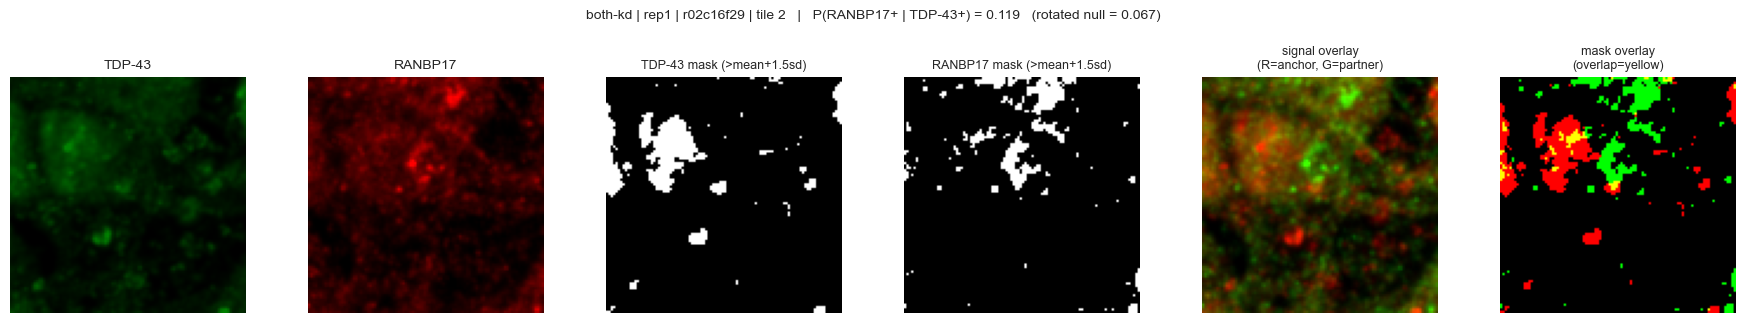

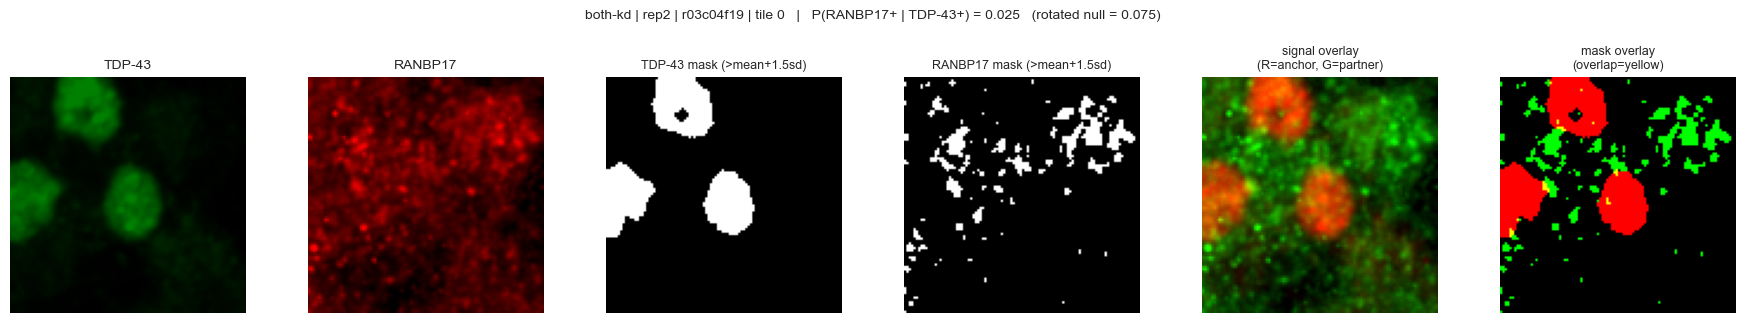

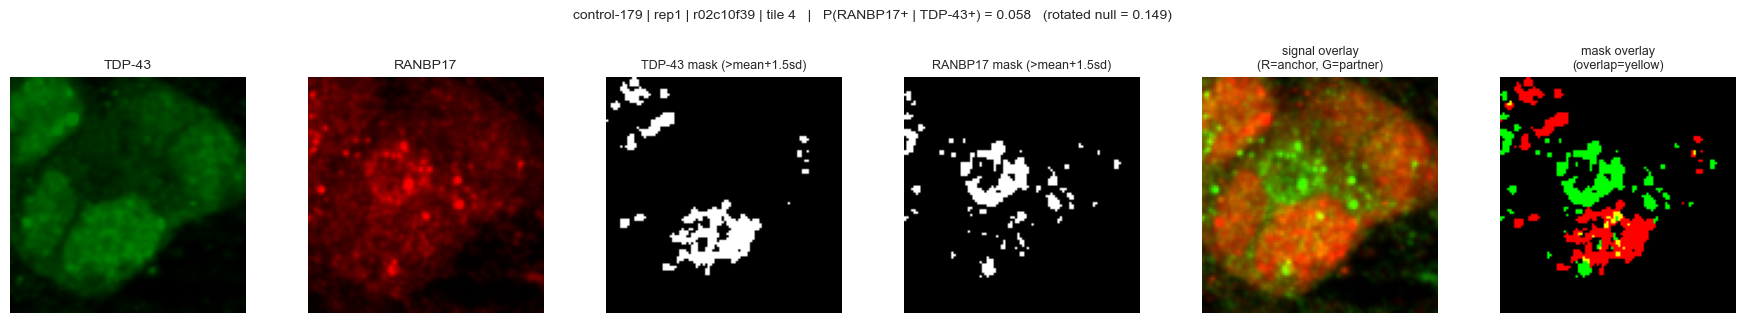

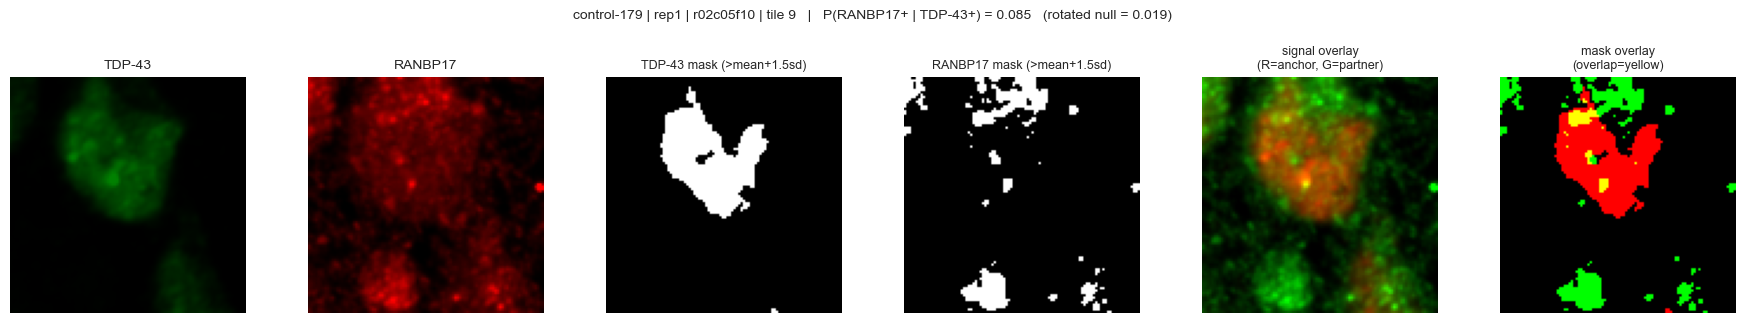

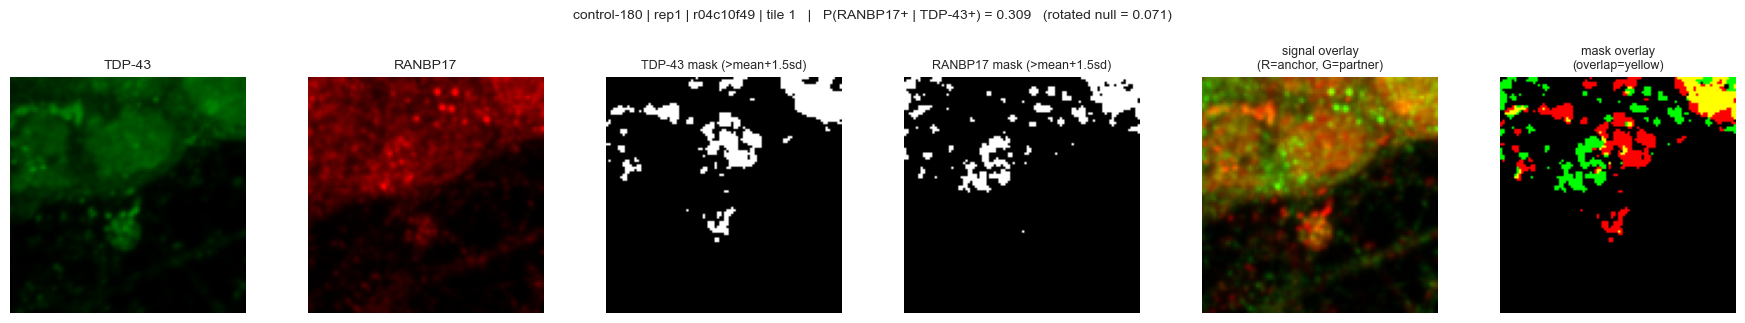

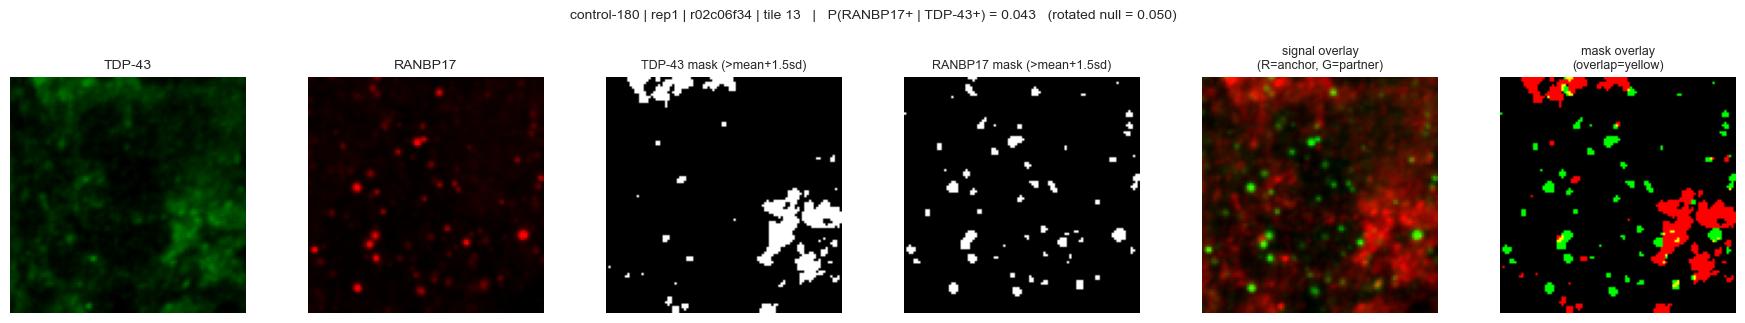

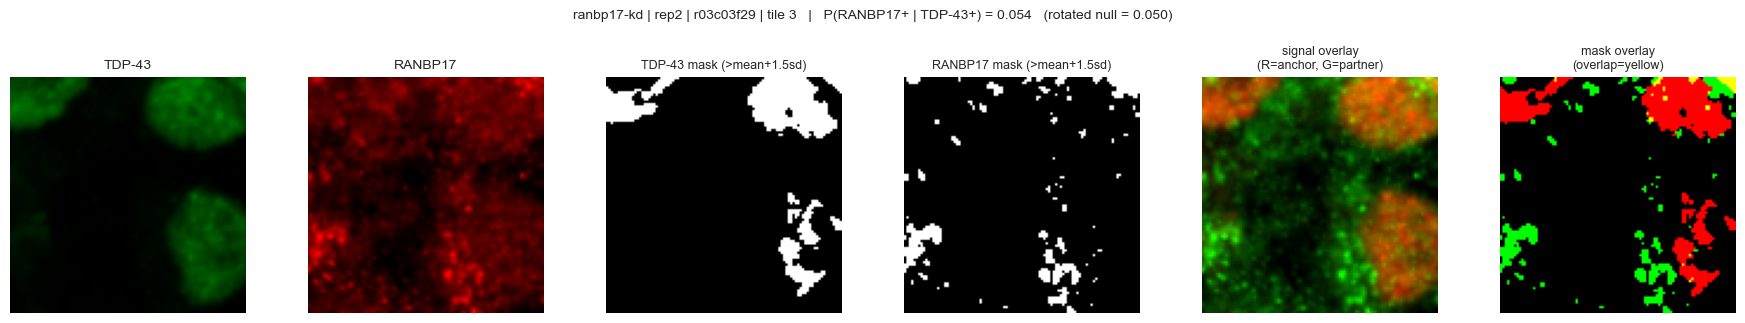

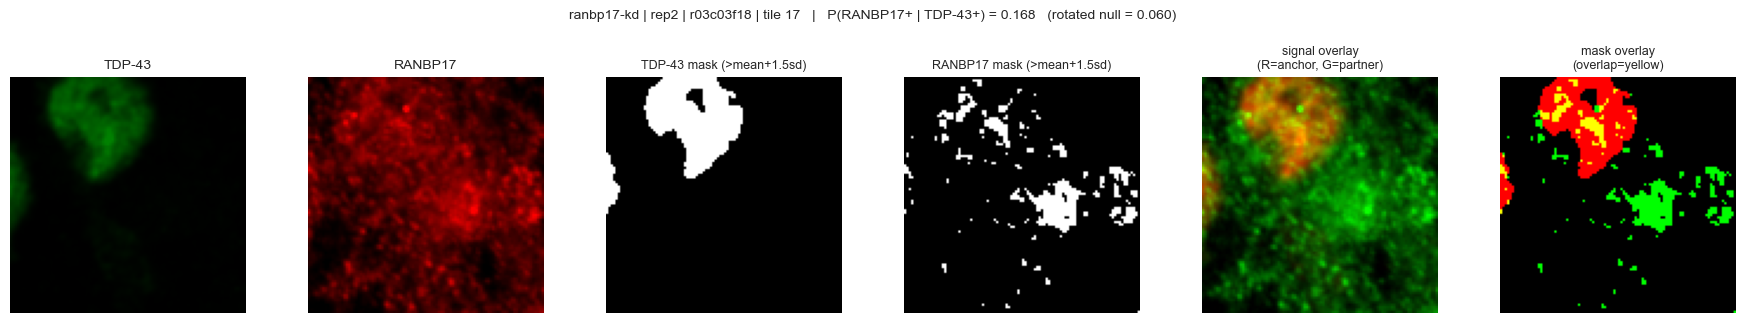

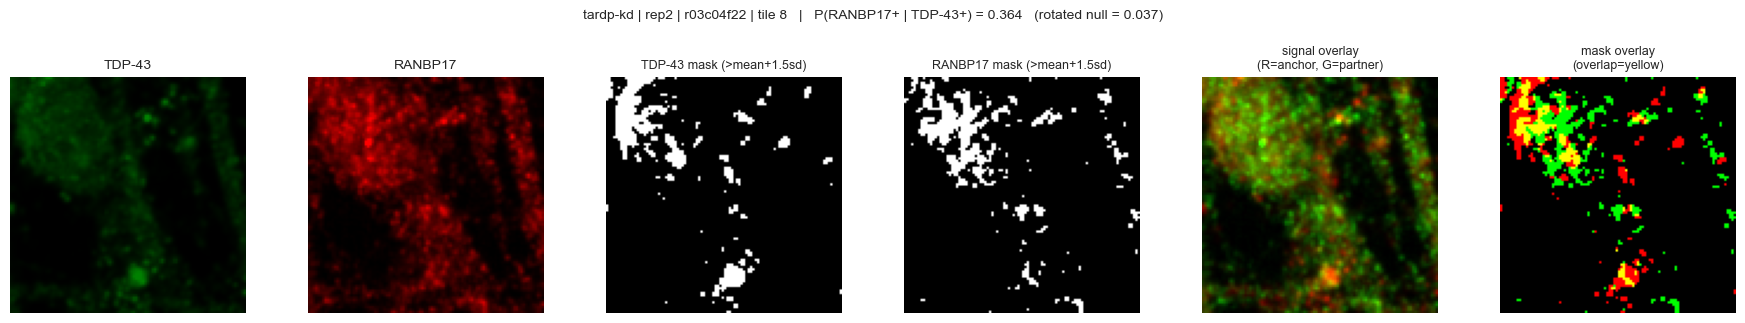

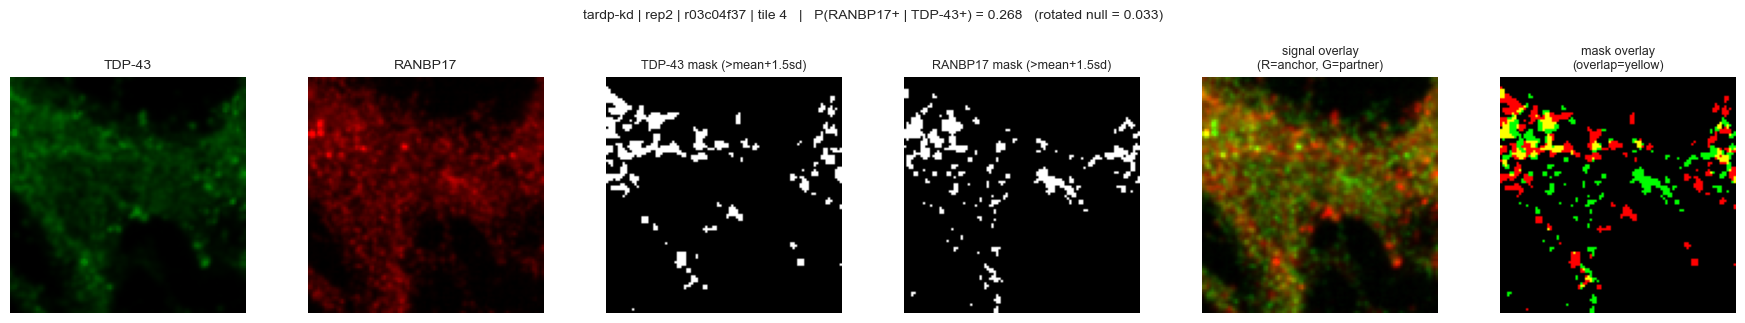

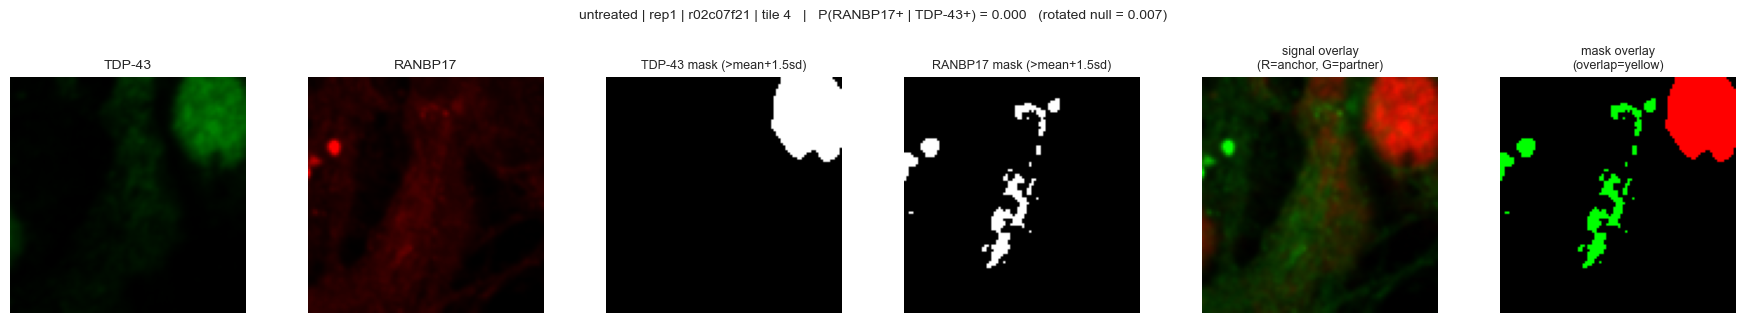

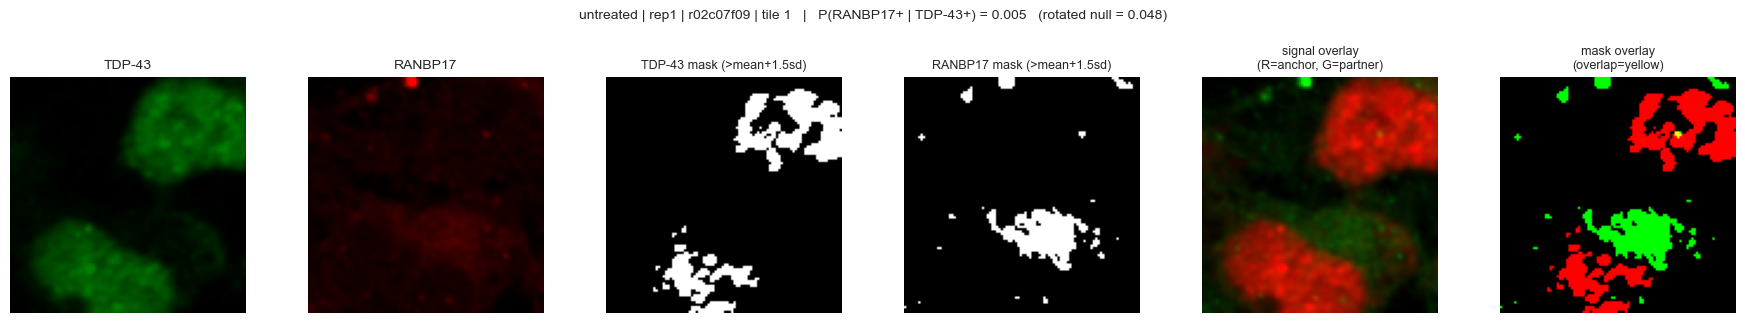

In [48]:
# Quick sanity-check viz: 2 tiles per condition.
output_dir = os.path.join(save_path, 'sample_tiles')
os.makedirs(output_dir, exist_ok=True)
show_sample_tiles(
    df_overlap,
    n_per_condition=2,
    output_dir=output_dir,
);

In [49]:
# Persist the scored tiles (drop the array column before writing CSV).
csv_path = os.path.join(save_path, f'{ANCHOR_MARKER}_{PARTNER_MARKER}_fraction_overlap_tiles.csv')
df_overlap.drop(columns=['tile_data']).to_csv(csv_path, index=False)
print('Saved scored per-tile DataFrame to', csv_path)

Saved scored per-tile DataFrame to /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/tiles/batch1-batch3/TDP-43_RANBP17/ancK1.5_partK1.5/TDP-43_RANBP17_fraction_overlap_tiles.csv


## Plot real vs rotated fraction_overlap distributions

Expect a clear right-shift of the real distribution if RANBP17 and TDP-43 colocalize above chance.

After dropna: 13221/13221 tiles have scores.


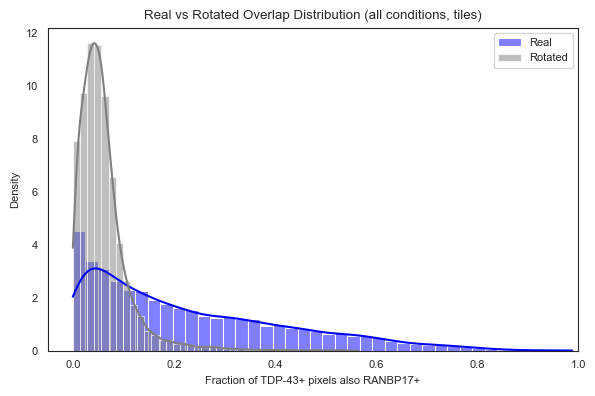

In [50]:
df_clean = df_overlap.dropna(subset=['fraction_overlap', 'fraction_overlap_rotated']).copy()
df_clean['fraction_overlap']         = df_clean['fraction_overlap'].astype(float)
df_clean['fraction_overlap_rotated'] = df_clean['fraction_overlap_rotated'].astype(float)
print(f"After dropna: {len(df_clean)}/{len(df_overlap)} tiles have scores.")

plt.figure(figsize=(6, 4))
sns.histplot(df_clean['fraction_overlap'],         label='Real',    color='blue', kde=True, stat='density', bins=40)
sns.histplot(df_clean['fraction_overlap_rotated'], label='Rotated', color='gray', kde=True, stat='density', bins=40)
plt.xlabel(f'Fraction of {ANCHOR_MARKER}+ pixels also {PARTNER_MARKER}+')
plt.ylabel('Density')
plt.title('Real vs Rotated Overlap Distribution (all conditions, tiles)')
plt.legend()
plt.xlim(-0.05, 1)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'fraction_overlap_{ANCHOR_MARKER}_{PARTNER_MARKER}_real_vs_rotated_all_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

## Summary statistics — aggregate by condition / rep

In [51]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch1,both-kd,rep1,0.307170,0.200691,512
1,batch1,both-kd,rep2,0.285640,0.205557,546
2,batch1,control-179,rep1,0.291159,0.197283,454
3,batch1,control-179,rep2,0.272308,0.194784,522
4,batch1,control-180,rep1,0.285302,0.198253,518
5,batch1,control-180,rep2,0.284065,0.200550,601
6,batch1,ranbp17-kd,rep1,0.308276,0.199184,498
7,batch1,ranbp17-kd,rep2,0.299032,0.201804,496
8,batch1,tardp-kd,rep1,0.317457,0.199556,562
9,batch1,tardp-kd,rep2,0.279014,0.195864,506


In [52]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap_rotated'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch1,both-kd,rep1,0.066154,0.066942,512
1,batch1,both-kd,rep2,0.060907,0.054147,546
2,batch1,control-179,rep1,0.060811,0.052375,454
3,batch1,control-179,rep2,0.065598,0.062446,522
4,batch1,control-180,rep1,0.063633,0.057605,518
5,batch1,control-180,rep2,0.058405,0.050389,601
6,batch1,ranbp17-kd,rep1,0.056049,0.055510,498
7,batch1,ranbp17-kd,rep2,0.059880,0.063586,496
8,batch1,tardp-kd,rep1,0.062804,0.054509,562
9,batch1,tardp-kd,rep2,0.066337,0.067391,506


## Step 3: Pairwise KD-vs-control effect-size models

Each KD condition is tested **separately** against each control in `KD_VS_CONTROL_PAIRS`
(e.g. `tardp-kd` vs `control-179`, `ranbp17-kd` vs `control-179`, …), rather than pooling all
KDs vs all controls. Per pair we fit `fraction_overlap ~ C(group)` with a random intercept for
batch and rep nested within batch (mixed model), falling back to replicate-level OLS on
per-(batch, rep) means if the variance components are singular. Reference = the control, so
**β > 0 means higher colocalization under KD**. p-values are FDR-corrected (Benjamini–Hochberg)
across all pairs, and effect sizes ±95% CI are shown as a forest plot. Needs ≥2 batches.

Pairwise KD vs control (beta > 0 = higher colocalization under KD):
                 contrast      beta     ci_lo     ci_hi     pval  pval_fdr sig   model  n_tiles_kd  n_tiles_ctrl  n_batches
  tardp-kd vs control-179 -0.012641 -0.024157 -0.001125 0.031441  0.094323  ns mixedlm        2404          1983          2
   both-kd vs control-179 -0.014423 -0.026733 -0.002113 0.021655  0.094323  ns mixedlm        1947          1983          2
ranbp17-kd vs control-180  0.007966 -0.002175  0.018107 0.123663  0.247327  ns mixedlm        2613          2569          2
   both-kd vs control-180 -0.007333 -0.018546  0.003881 0.199976  0.299963  ns mixedlm        1947          2569          2
  tardp-kd vs control-180 -0.003990 -0.014376  0.006395 0.451400  0.541680  ns mixedlm        2404          2569          2
ranbp17-kd vs control-179  0.000015 -0.011263  0.011294 0.997867  0.997867  ns mixedlm        2613          1983          2

Saved pairwise results to /home/projects/hornsteinlab/Collabora

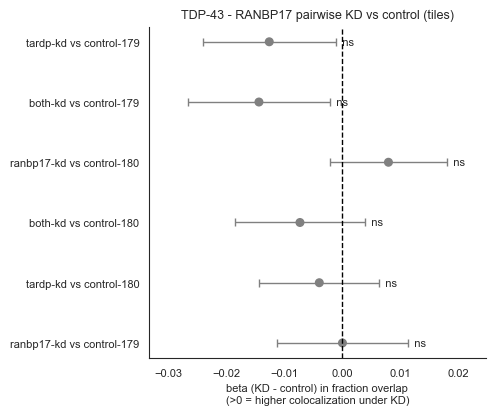

In [53]:
# ---- Step 3: Pairwise KD-vs-control, one model per (KD, control) pair ----
# KD-vs-control is a BETWEEN-group contrast, so tiles within a rep are pseudoreplicates: the
# replicate (batch, rep) is the unit. Per pair we fit
#   fraction_overlap ~ C(group), random intercept for batch + rep nested within batch,
# control as the reference level (so beta > 0 = HIGHER colocalization under KD).
# Fallback (singular variance components): OLS on per-(batch, rep) means with batch as a fixed
# block. p-values are FDR-corrected across pairs. Needs >=2 batches.
import statsmodels.formula.api as smf
import warnings
from statsmodels.stats.multitest import multipletests

COEF = 'C(group)[T.KD]'

def test_kd_vs_control(data, kd_cond, ctrl_cond):
    """Fit one KD-vs-control contrast; return a result row (beta, CI, p, model, counts)."""
    sub = data[data['condition'].isin([kd_cond, ctrl_cond])].copy()
    n_kd, n_ctrl = (sub['condition'] == kd_cond).sum(), (sub['condition'] == ctrl_cond).sum()
    row = {'kd': kd_cond, 'control': ctrl_cond, 'n_tiles_kd': int(n_kd),
           'n_tiles_ctrl': int(n_ctrl), 'n_batches': sub['batch'].nunique(),
           'beta': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan, 'pval': np.nan, 'model': 'skipped'}
    if row['n_batches'] < 2 or n_kd == 0 or n_ctrl == 0:
        return row
    sub['group'] = np.where(sub['condition'] == kd_cond, 'KD', 'control')
    sub['group'] = pd.Categorical(sub['group'], categories=['control', 'KD'])  # ref = control
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            md = smf.mixedlm('fraction_overlap ~ C(group)', sub, groups=sub['batch'],
                             vc_formula={'rep': '0 + C(rep)'})   # rep nested within batch
            res = md.fit(reml=False, method='lbfgs', disp=False)
        if not np.isfinite(res.bse.get(COEF, np.nan)):
            raise ValueError('non-finite SE (singular fit)')
        row['model'] = 'mixedlm'
    except Exception:
        agg = (sub.groupby(['batch', 'rep', 'group'], observed=True)['fraction_overlap']
                  .mean().reset_index())
        res = smf.ols('fraction_overlap ~ C(group) + C(batch)', agg).fit()
        row['model'] = 'ols_fallback'
    row['beta'] = res.params[COEF]
    row['ci_lo'], row['ci_hi'] = res.conf_int().loc[COEF]
    row['pval'] = res.pvalues[COEF]
    return row

results = pd.DataFrame(
    [test_kd_vs_control(df_clean, kd, ctrl) for kd, ctrl in KD_VS_CONTROL_PAIRS]
)
results['contrast'] = results['kd'] + ' vs ' + results['control']
# FDR across the testable pairs only.
mask = results['pval'].notna()
results['pval_fdr'] = np.nan
if mask.any():
    results.loc[mask, 'pval_fdr'] = multipletests(results.loc[mask, 'pval'], method='fdr_bh')[1]

def _stars(p):
    if not np.isfinite(p): return 'n/a'
    return '****' if p < 1e-4 else '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'
results['sig'] = results['pval_fdr'].map(_stars)

results = results.sort_values('pval_fdr', na_position='last').reset_index(drop=True)
cols = ['contrast', 'beta', 'ci_lo', 'ci_hi', 'pval', 'pval_fdr', 'sig',
        'model', 'n_tiles_kd', 'n_tiles_ctrl', 'n_batches']
print('Pairwise KD vs control (beta > 0 = higher colocalization under KD):')
print(results[cols].to_string(index=False))

pairwise_csv = os.path.join(save_path, f'KD_vs_control_pairwise_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.csv')
results[cols].to_csv(pairwise_csv, index=False)
print('\nSaved pairwise results to', pairwise_csv)

# ---- Forest plot of all contrasts (beta +/- 95% CI) ----
plot_df = results[results['beta'].notna()].iloc[::-1].reset_index(drop=True)  # best p at top
if plot_df.empty:
    print('No testable contrasts to plot (need >=2 batches per pair).')
else:
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(plot_df) + 1.2))
    y = np.arange(len(plot_df))
    sig_color = {'ns': 'gray'}
    colors = [sig_color.get(s, '#c0392b') for s in plot_df['sig']]
    ax.errorbar(plot_df['beta'], y,
                xerr=[plot_df['beta'] - plot_df['ci_lo'], plot_df['ci_hi'] - plot_df['beta']],
                fmt='none', ecolor='gray', elinewidth=1, capsize=3, zorder=1)
    ax.scatter(plot_df['beta'], y, c=colors, s=30, zorder=2)
    ax.axvline(0, color='black', lw=1, ls='--')
    for yi, (_, r) in zip(y, plot_df.iterrows()):
        ax.text(r['ci_hi'], yi, f"  {r['sig']}", va='center', ha='left', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['contrast'])
    ax.set_xlabel('beta (KD - control) in fraction overlap\n(>0 = higher colocalization under KD)')
    ax.set_title(f'{ANCHOR_MARKER} - {PARTNER_MARKER} pairwise KD vs control (tiles)', fontsize=9)
    ax.margins(x=0.15)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'KD_vs_control_forest_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'),
                dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(save_path, f'KD_vs_control_forest_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.eps'),
                dpi=300, bbox_inches='tight')
    plt.show()

## Step 4: Replicate-level real vs rotated (paired test + mixed model)

Tests whether colocalization is above the rotation null, using the replicate (batch × rep) as the
unit (tiles are pseudoreplicates). Run for three groupings, defined once in `REPL_GROUPS`:
1. **All controls** pooled (`PAIRWISE_CONTROLS` = control-179 + control-180; untreated excluded);
2. **All KDs** pooled (`KD_CONDITIONS`);
3. **Each condition separately** (every entry in `CONDITIONS`).

The paired replicate-level test (sign / Wilcoxon / t-test) and the per-tile mixed model
(`run_analysis_generate_report`, batch random effect) are each applied to every grouping.
Inference needs ≥2 batches. `repl_all` (all conditions pooled) is also computed for the Step 5 plot star.

In [ ]:
# ---- Step 4: Replicate-level real vs rotated (publishable inference) ----
# Primary significance for "is colocalization real?" uses the biological/technical replicate
# as the unit, NOT individual tiles (tiles are pseudoreplicates). We aggregate to per-(batch, rep)
# means and test real > rotated across those units. Requires >=2 batches for inference.
from scipy.stats import wilcoxon, ttest_rel, binomtest

REPL_KEYS = ['batch', 'rep']   # one replicate unit per (batch, rep)

def replicate_level_test(data, label):
    agg = (data.groupby(REPL_KEYS)[['fraction_overlap', 'fraction_overlap_rotated']]
               .mean().reset_index())
    n_units = len(agg)
    n_batches = data['batch'].nunique()
    print(f"=== {label} ===")
    print(agg.to_string(index=False))
    print(f"replicate units (batch x rep): {n_units}; batches: {n_batches}")
    if n_batches < 2:
        print("-> descriptive only, insufficient replication for inference (need >=2 batches).\n")
        return None
    real = agg['fraction_overlap'].to_numpy(dtype=float)
    rot  = agg['fraction_overlap_rotated'].to_numpy(dtype=float)
    diff = real - rot
    n_pos = int((diff > 0).sum()); n_eff = int((diff != 0).sum())
    out = {'label': label, 'n_units': n_units, 'n_batches': n_batches,
           'mean_real': float(real.mean()), 'mean_rot': float(rot.mean()),
           'mean_diff': float(diff.mean())}
    out['sign_p'] = float(binomtest(n_pos, n_eff, 0.5, alternative='greater').pvalue) if n_eff else float('nan')
    try:
        out['wilcoxon_p'] = float(wilcoxon(real, rot, alternative='greater').pvalue)
    except ValueError as e:
        out['wilcoxon_p'] = float('nan'); print(f"  wilcoxon n/a: {e}")
    t, p_two = ttest_rel(real, rot)
    out['ttest_p'] = float(p_two / 2 if t > 0 else 1 - p_two / 2)
    print(f"  mean real={out['mean_real']:.4f}  rotated={out['mean_rot']:.4f}  delta={out['mean_diff']:+.4f}")
    print(f"  sign test (real>rot in {n_pos}/{n_eff}): p={out['sign_p']:.4g}")
    print(f"  paired Wilcoxon (greater): p={out['wilcoxon_p']:.4g}")
    print(f"  paired t-test (greater):   p={out['ttest_p']:.4g}\n")
    return out

# Groupings (shared with the mixed model below): pooled controls, pooled KDs, then each condition.
REPL_GROUPS = [
    ('All controls (control-179 + control-180)', PAIRWISE_CONTROLS),
    ('All KDs', KD_CONDITIONS),
    *[(cond, [cond]) for cond in CONDITIONS],
]

repl_results = {
    label: replicate_level_test(df_clean[df_clean['condition'].isin(conds)], label)
    for label, conds in REPL_GROUPS
}

# Pooled-across-all-conditions test, kept for the Step 5 significance annotation.
repl_all = replicate_level_test(df_clean, 'All conditions (Step 5 annotation)')

In [ ]:
# ---- Step 4b: Mixed model for real vs rotated (random intercept for batch) ----
# Supplementary to the replicate-level paired test. Per-tile rows with batch as a random effect;
# reference level = Rotated, so the reported 'Real' coefficient = colocalization above the null.
# Applied to the same REPL_GROUPS (pooled controls, pooled KDs, each condition). Needs >=2 batches.
def mixed_model_real_vs_rotated(data, label):
    print(f"=== Mixed model: {label} ===")
    if not HAS_EFFECT_SIZE_REPORT:
        print('run_analysis_generate_report not loaded - skipping.\n'); return None
    n_batches = data['batch'].nunique()
    if n_batches < 2:
        print(f'Only {n_batches} batch present - descriptive only (mixed model needs >=2 batches).\n')
        return None
    long_rr = data.melt(
        id_vars=['batch', 'rep', 'condition'],
        value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
        var_name='metric', value_name='value',
    )
    long_rr['metric'] = long_rr['metric'].map(
        {'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated'})
    long_rr['metric'] = pd.Categorical(long_rr['metric'], categories=['Rotated', 'Real'])
    res = run_analysis_generate_report(
        df=long_rr, feature_columns=['value'],
        group_col='metric', batch_col='batch', output_dir=None)
    display(res)
    print()
    return res

mixed_results = {
    label: mixed_model_real_vs_rotated(df_clean[df_clean['condition'].isin(conds)], label)
    for label, conds in REPL_GROUPS
}

## Step 5: Per-condition / per-rep visualization — boxplot + jittered scatter

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


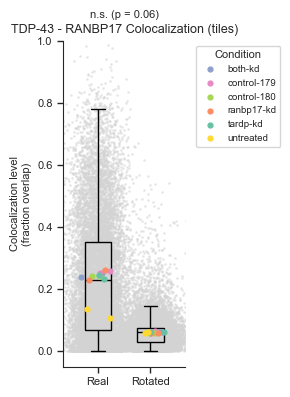

In [56]:
df_long = df_clean.melt(
    id_vars=['batch', 'condition', 'rep'],
    value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
    var_name='metric', value_name='value',
)
df_long['metric'] = df_long['metric'].replace({
    'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated',
})

fig, ax = plt.subplots(figsize=(3, 4))
line_width = 1
sns.set_style('white')
x_pos_map = {'Real': 0, 'Rotated': 0.3}

for metric, xpos in x_pos_map.items():
    data_subset = df_long[df_long['metric'] == metric]
    sns.boxplot(
        data=data_subset, y='value', ax=ax,
        width=0.15, linewidth=line_width,
        showmeans=True, showfliers=False, meanline=True,
        meanprops={'linestyle': '-', 'color': 'black', 'linewidth': line_width},
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=line_width),
        whiskerprops=dict(linewidth=line_width, color='black'),
        capprops=dict(linewidth=line_width, color='black'),
        medianprops=dict(visible=False),
        positions=[xpos],
    )
    x_jittered = np.random.normal(loc=xpos, scale=0.08, size=len(data_subset))
    ax.scatter(x=x_jittered, y=data_subset['value'], color='lightgray', s=1, alpha=0.4, zorder=1)

# Per-(condition,rep) means as colored dots.
group_means = df_long.groupby(['condition', 'rep', 'metric'])['value'].mean().reset_index()
cond_order = [c for c in CONDITIONS if c in group_means['condition'].unique()]
color_map = dict(zip(cond_order, sns.color_palette('Set2', n_colors=len(cond_order))))
for _, row in group_means.iterrows():
    xp = x_pos_map[row['metric']]
    jittered_x = np.random.normal(loc=xp, scale=0.04)
    ax.scatter(x=jittered_x, y=row['value'], color=color_map.get(row['condition'], 'black'),
               edgecolor=None, s=12, label=row['condition'], zorder=3)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Condition',
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

# Star from the replicate-level test (Step 4) - NOT the per-tile pool (pseudoreplication).
try:
    _repl = repl_all
except NameError:
    _repl = None
p = None
if _repl is not None:
    p = _repl['wilcoxon_p'] if np.isfinite(_repl.get('wilcoxon_p', np.nan)) else _repl.get('sign_p', np.nan)
if p is None or not np.isfinite(p):
    p_text = 'descriptive\n(insufficient reps)'
elif p < 0.0001: p_text = '****'
elif p < 0.001:  p_text = '***'
elif p < 0.01:   p_text = '**'
elif p < 0.05:   p_text = '*'
else:            p_text = f'n.s. (p = {p:.2f})'

ymin, ymax = ax.get_ylim()
y_range = ymax - ymin
line_y = ymax + 0.01 * ymax
ax.plot([0, 0, x_pos_map['Rotated'], x_pos_map['Rotated']],
        [line_y, line_y + 0.01 * ymax, line_y + 0.01 * ymax, line_y], lw=1.5, c='black')
ax.text(x_pos_map['Rotated'] / 2, line_y + 0.02 * ymax, p_text, ha='center', va='bottom', fontsize=8)

ax.tick_params(axis='both', which='both', direction='out', length=4, width=1,
               bottom=True, top=False, left=True, right=False)
ax.set_xticks(list(x_pos_map.values()))
ax.set_xticklabels(list(x_pos_map.keys()), rotation=0)
ax.set_ylim(ymin - 0.05 * y_range, ymax + 0.1 * y_range)
ax.set_xlim(min(x_pos_map.values()) - 0.2, max(x_pos_map.values()) + 0.2)

plt.ylabel('Colocalization level\n(fraction overlap)')
plt.title(f'{ANCHOR_MARKER} - {PARTNER_MARKER} Colocalization (tiles)', fontsize=9)
plt.xlabel('')
plt.ylim(-0.05, 1)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.eps'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=300, bbox_inches='tight')
plt.show()

## Coefficient of variation (CV) per condition

Replicate-level reproducibility within each condition. CV < 0.1 = excellent, 0.1–0.2 = acceptable, > 0.2 = high variability.

     condition      mean       std        CV
0      both-kd  0.239318  0.067060  0.280211
1  control-179  0.255281  0.031623  0.123874
2  control-180  0.246681  0.043889  0.177916
3   ranbp17-kd  0.256327  0.058709  0.229039
4     tardp-kd  0.244638  0.063934  0.261340
5    untreated  0.151819  0.131582  0.866701


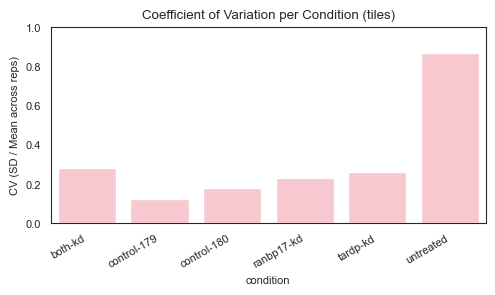

In [57]:
summary_per_rep = (
    df_clean.groupby(['condition', 'batch', 'rep'])['fraction_overlap']
    .mean().reset_index().sort_values(['condition', 'batch', 'rep'])
)
repro_stats = (
    summary_per_rep.groupby('condition')['fraction_overlap']
    .agg(['mean', 'std'])
    .assign(CV=lambda d: d['std'] / d['mean'])
    .reset_index()
)
print(repro_stats)

plt.figure(figsize=(5, 3))
sns.barplot(data=repro_stats, x='condition', y='CV', color='pink')
plt.title('Coefficient of Variation per Condition (tiles)')
plt.ylabel('CV (SD / Mean across reps)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Reproducibility: means per condition and replicate

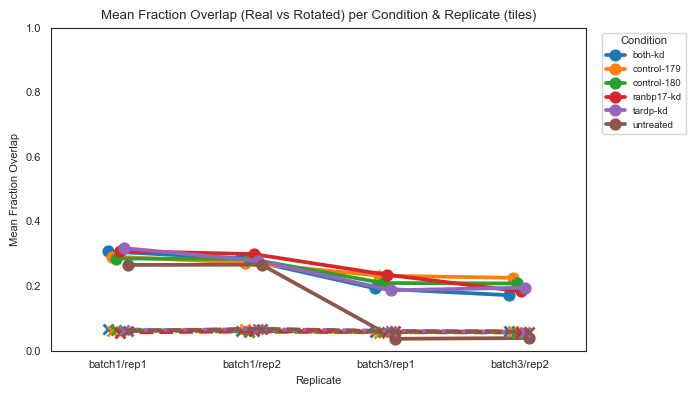

In [58]:
summary = (
    df_clean.groupby(['condition', 'batch', 'rep'])[['fraction_overlap', 'fraction_overlap_rotated']]
    .mean().reset_index()
)
summary['rep'] = summary['batch'].astype(str) + '/' + summary['rep'].astype(str)  # batch x rep unit

plt.figure(figsize=(7, 4))
sns.pointplot(data=summary, x='rep', y='fraction_overlap', hue='condition',
              markers='o', dodge=True, errorbar=None, linestyles='-')
sns.pointplot(data=summary, x='rep', y='fraction_overlap_rotated', hue='condition',
              markers='x', dodge=True, errorbar=None, linestyles='--', legend=False)
plt.title('Mean Fraction Overlap (Real vs Rotated) per Condition & Replicate (tiles)')
plt.ylabel('Mean Fraction Overlap')
plt.xlabel('Replicate')
plt.ylim(0, 1)
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_per_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

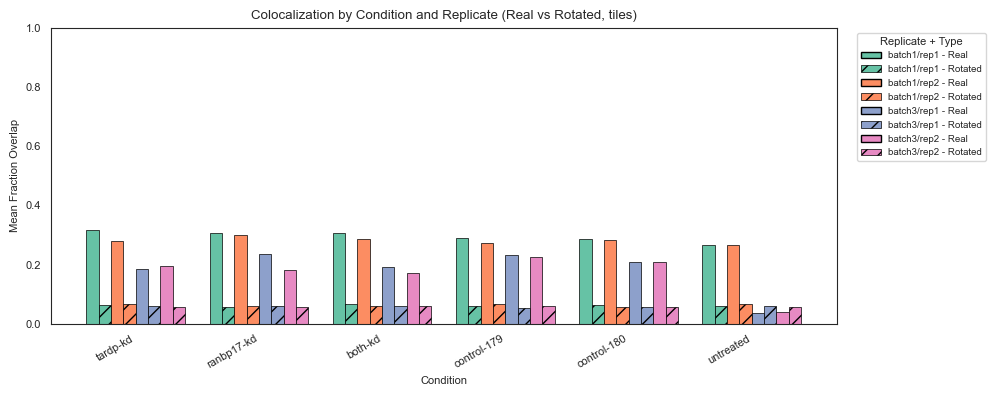

In [59]:
# Bar plot grouped by condition + replicate, Real vs Rotated (hatched).
long_df = pd.melt(summary, id_vars=['condition', 'rep'],
                  value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
                  var_name='type', value_name='overlap')
long_df['type'] = long_df['type'].map({'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated'})
long_df['rep_type'] = long_df['rep'].astype(str) + '-' + long_df['type']

conds = [c for c in CONDITIONS if c in long_df['condition'].unique()]
rep_order = sorted(long_df['rep'].unique())
base_palette = dict(zip(rep_order, sns.color_palette('Set2', n_colors=len(rep_order))))

plt.figure(figsize=(10, 4))
ax = plt.gca()
rep_type_order = sorted(long_df['rep_type'].unique())
bar_width = 0.8 / len(rep_type_order)
for i, cond in enumerate(conds):
    for j, rep_type in enumerate(rep_type_order):
        r = long_df[(long_df['condition'] == cond) & (long_df['rep_type'] == rep_type)]
        if r.empty:
            continue
        y = r['overlap'].values[0]; rep = r['rep'].values[0]
        is_rotated = 'Rotated' in rep_type
        xpos = i - 0.4 + j * bar_width + bar_width / 2
        ax.bar(xpos, y, width=bar_width, color=base_palette[rep], edgecolor='black',
               hatch='//' if is_rotated else '', linewidth=0.5,
               label=rep_type if i == 0 else None)

ax.set_xticks(range(len(conds)))
ax.set_xticklabels(conds, rotation=30, ha='right')
ax.set_xlabel('Condition'); ax.set_ylabel('Mean Fraction Overlap'); ax.set_ylim(0, 1)
ax.set_title('Colocalization by Condition and Replicate (Real vs Rotated, tiles)')

legend_patches = []
for rep in rep_order:
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', label=f'{rep} - Real'))
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', hatch='//', label=f'{rep} - Rotated', linewidth=0.5))
ax.legend(handles=legend_patches, title='Replicate + Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_bars_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

In [60]:
print('Done!')

Done!
